# Libraries

In [53]:
import pandas as pd
import numpy as np

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from IPython.display import Image, display
import os
import matplotlib.font_manager as fm
import time
import warnings
import statsmodels.api as sm

# Plotting Libs
import matplotlib.pyplot as plt 
from sklearn.tree import plot_tree
from xgboost import plot_importance
import shap

# Scaler Libs
from sklearn.preprocessing import MinMaxScaler

# CV Libs
from sklearn.model_selection import GridSearchCV 
from xgboost import XGBClassifier

# Accuracy Libs
from sklearn.metrics import accuracy_score , classification_report, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import average_precision_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import f1_score

# Resampling Libs
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler

# Load Plots

In [54]:
# ROC_AIC Plots
roc1 = f"roc_plots/roc_df1.png"
roc2 = f"roc_plots/roc_df2.png"
roc3 = f"roc_plots/roc_df3.png"
roc4 = f"roc_plots/roc_df4.png"

# SHAP Plots
lgb_shap1 = f"shap_plots/df1_LightGBM_shap_plot.png"
lgb_shap2 = f"shap_plots/df2_LightGBM_shap_plot.png"
lgb_shap3 = f"shap_plots/df3_LightGBM_shap_plot.png"
lgb_shap4 = f"shap_plots/df4_LightGBM_shap_plot.png"

xgb_shap1 = f"shap_plots/df1_XGBoost_shap_plot.png"
xgb_shap2 = f"shap_plots/df2_XGBoost_shap_plot.png"
xgb_shap3 = f"shap_plots/df3_XGBoost_shap_plot.png"
xgb_shap4 = f"shap_plots/df4_XGBoost_shap_plot.png"

gb_shap1 = f"shap_plots/df1_GBoost_shap_plot.png"
gb_shap2 = f"shap_plots/df2_GBoost_shap_plot.png"
gb_shap3 = f"shap_plots/df3_GBoost_shap_plot.png"
gb_shap4 = f"shap_plots/df4_GBoost_shap_plot.png"

# SHAP Mean Values
lgb_values1 = pd.read_pickle(r".\shap_plots\df1_LightGBM_mean_shap.pkl")
lgb_values2 = pd.read_pickle(r".\shap_plots\df2_LightGBM_mean_shap.pkl")
lgb_values3 = pd.read_pickle(r".\shap_plots\df3_LightGBM_mean_shap.pkl")
lgb_values4 = pd.read_pickle(r".\shap_plots\df4_LightGBM_mean_shap.pkl")

xgb_values1 = pd.read_pickle(r".\shap_plots\df1_XGBoost_mean_shap.pkl")
xgb_values2 = pd.read_pickle(r".\shap_plots\df2_XGBoost_mean_shap.pkl")
xgb_values3 = pd.read_pickle(r".\shap_plots\df3_XGBoost_mean_shap.pkl")
xgb_values4 = pd.read_pickle(r".\shap_plots\df4_XGBoost_mean_shap.pkl")

gb_values1 = pd.read_pickle(r".\shap_plots\df1_GBoost_mean_shap.pkl")
gb_values2 = pd.read_pickle(r".\shap_plots\df2_GBoost_mean_shap.pkl")
gb_values3 = pd.read_pickle(r".\shap_plots\df3_GBoost_mean_shap.pkl")
gb_values4 = pd.read_pickle(r".\shap_plots\df4_GBoost_mean_shap.pkl")

# Accuracy, Classification report, MCC
metrics1 = pd.read_pickle(f"./shap_plots/df1_metrics.pkl")
metrics2 = pd.read_pickle(f"./shap_plots/df2_metrics.pkl")
metrics3 = pd.read_pickle(f"./shap_plots/df3_metrics.pkl")
metrics4 = pd.read_pickle(f"./shap_plots/df4_metrics.pkl")



In [55]:
# One figure per Phase
# One figure per Phase
    
def fun_fig_roc(path1):
    img1 = mpimg.imread(path1)
    plt.figure(figsize=(10, 5))
    plt.imshow(img1)
    plt.axis('off')
    #plt.title(f'ROC / PR Curves - Phase {i}', fontweight='bold')
    plt.tight_layout()
    plt.show()

##################################################################################
    
def fun_fig_shap(path2, path3 = None):
    img2 = mpimg.imread(path2)

    plt.figure(figsize=(10, 5))
    plt.imshow(img2)
    plt.axis('off')
    #plt.title(f'SHAP plot - Phase {i}', fontweight='bold')
    plt.tight_layout()
    plt.show()

    if path3 is not None:
        img3 = mpimg.imread(path3)

        plt.figure(figsize=(10, 5))
        plt.imshow(img3)
        plt.axis('off')
        #plt.title(f'SHAP plot - Phase {i}', fontweight='bold')
        plt.tight_layout()
        plt.show()


# ROC_AUC

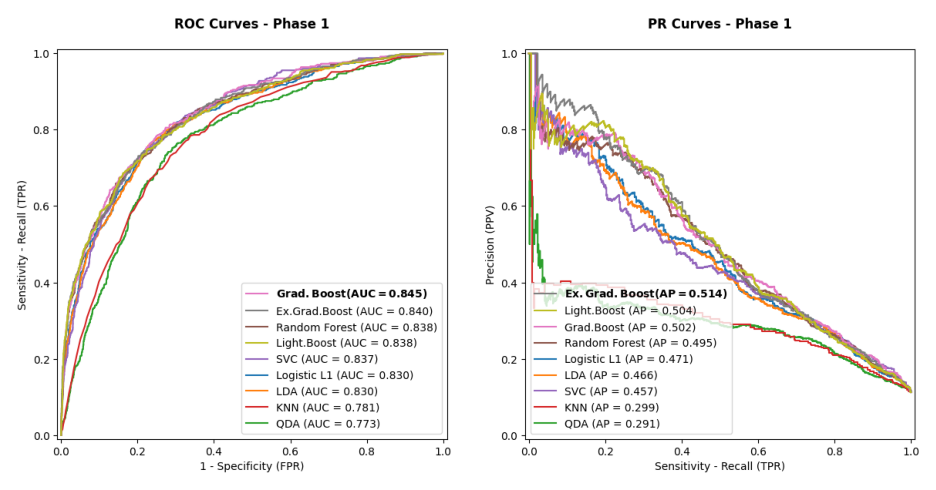

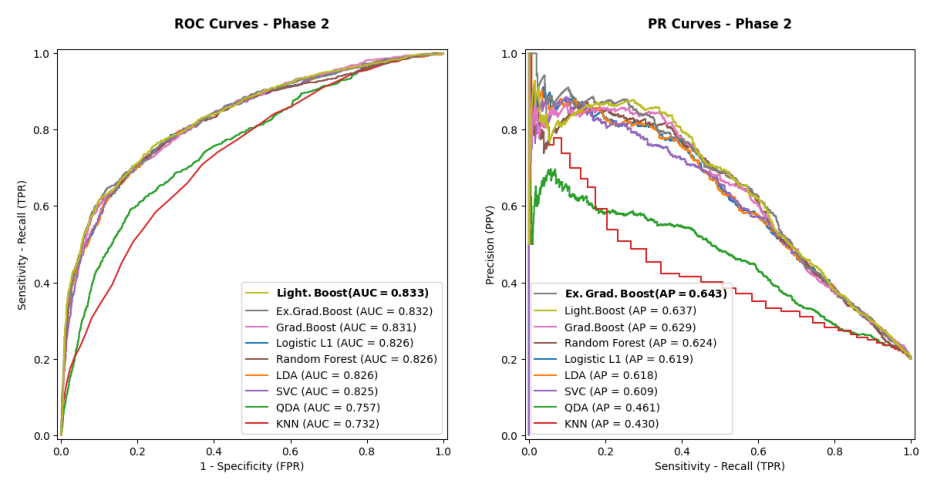

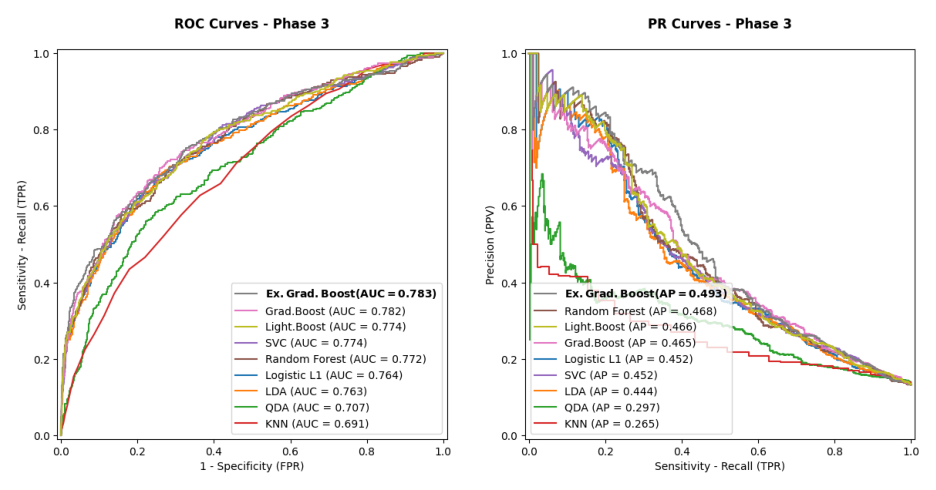

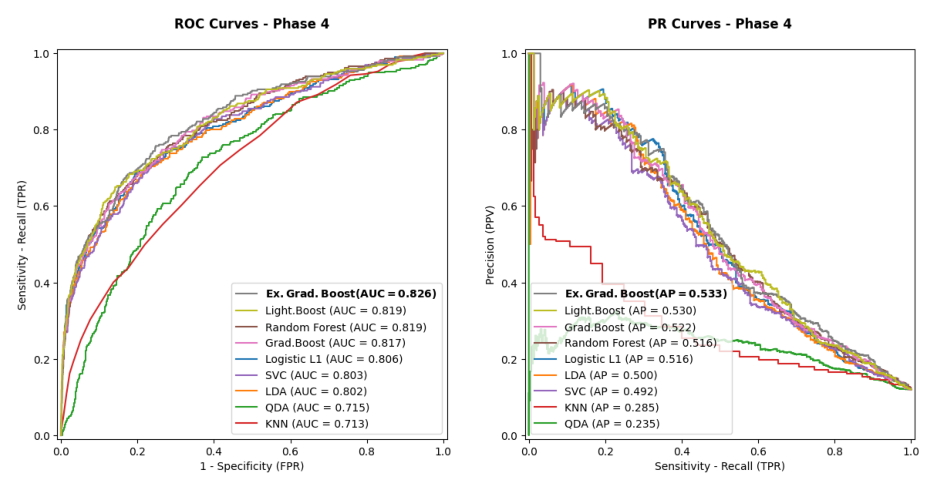

In [56]:
fun_fig_roc(roc1)
fun_fig_roc(roc2)
fun_fig_roc(roc3)
fun_fig_roc(roc4)

# Shap Plots

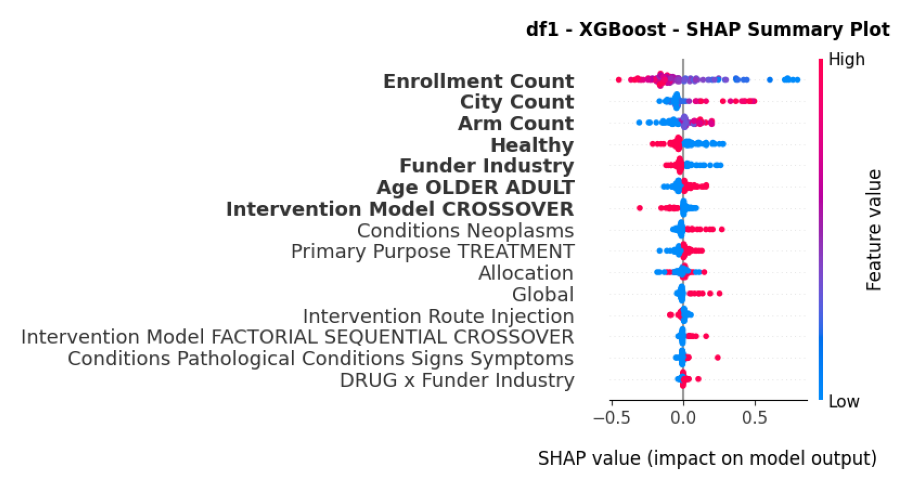

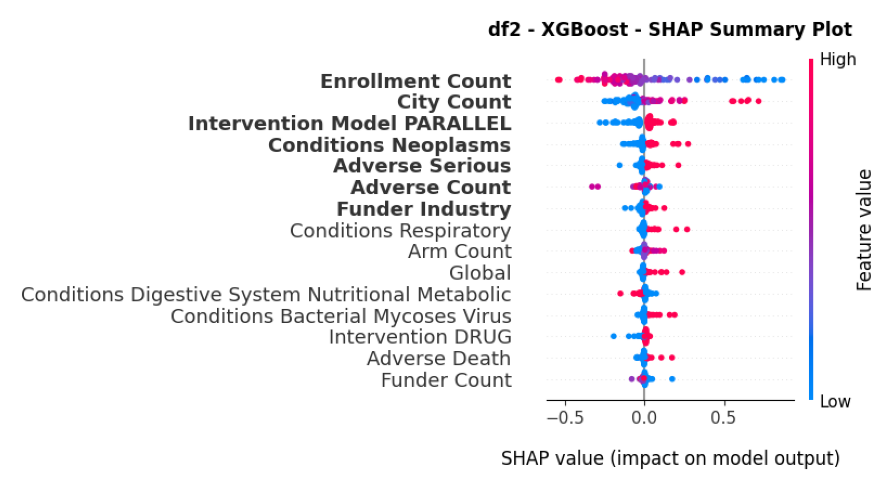

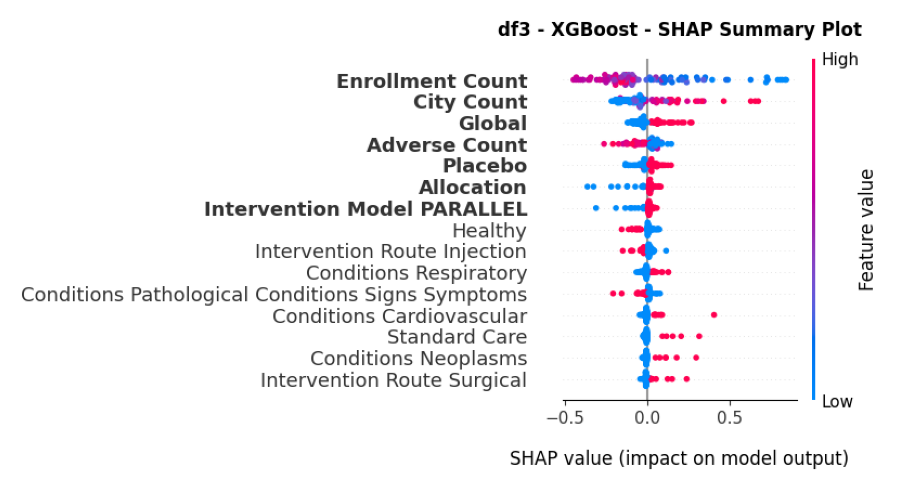

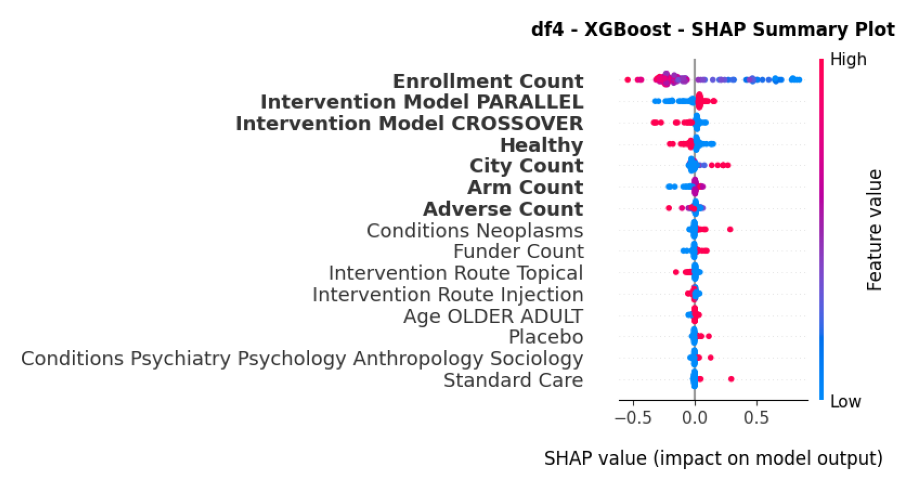

In [57]:
fun_fig_shap(xgb_shap1)
fun_fig_shap(xgb_shap2)
fun_fig_shap(xgb_shap3)
fun_fig_shap(xgb_shap4)

# Metrics

In [58]:
def fun_metrics(metrics, i):
    metrics = metrics.sort_values(by = ['MCC', 'BACC', 'F1'], ascending = False)
    metrics = metrics.reset_index(drop=True)
    metrics.index.name = f'df{i}'
 
    first_idx = metrics.index[0]
    metrics.loc[first_idx] = metrics.loc[first_idx].apply(lambda x: f"**{x}**")
    return metrics

metrics1 = fun_metrics(metrics1, 1)
metrics2 = fun_metrics(metrics2, 2)
metrics3 = fun_metrics(metrics3, 3)
metrics4 = fun_metrics(metrics4, 4)

display(metrics1, metrics2, metrics3, metrics4)

,Models,BACC,MCC,F1
df1,,,,
0,**Grad_Boost**,**76.441%**,**0.372**,**0.812**
1,LightGBM,76.082%,0.366,0.809
2,Ex_Grad_Boost,76.042%,0.365,0.809
3,Logistic,76.357%,0.362,0.797
4,Random_Forest,75.647%,0.361,0.809
5,LDA,76.250%,0.359,0.796
6,SVC,75.850%,0.353,0.793
7,QDA,72.045%,0.303,0.785
8,KNN,72.160%,0.295,0.761


,Models,BACC,MCC,F1
df2,,,,
0,**LightGBM**,**75.711%**,**0.456**,**0.806**
1,Random_Forest,75.600%,0.456,0.808
2,Grad_Boost,75.839%,0.455,0.804
3,Ex_Grad_Boost,75.649%,0.452,0.803
4,SVC,75.317%,0.439,0.793
5,LDA,75.129%,0.428,0.783
6,Logistic,75.098%,0.425,0.779
7,QDA,67.650%,0.283,0.663
8,KNN,66.487%,0.270,0.699


,Models,BACC,MCC,F1
df3,,,,
0,**Grad_Boost**,**71.869%**,**0.318**,**0.774**
1,Ex_Grad_Boost,71.344%,0.317,0.784
2,Random_Forest,69.733%,0.305,0.796
3,LightGBM,69.986%,0.300,0.784
4,LDA,70.392%,0.289,0.749
5,Logistic,70.185%,0.286,0.748
6,SVC,70.129%,0.286,0.749
7,QDA,64.071%,0.192,0.666
8,KNN,63.226%,0.183,0.694


,Models,BACC,MCC,F1
df4,,,,
0,**Ex_Grad_Boost**,**75.388%**,**0.390**,**0.834**
1,LightGBM,74.826%,0.389,0.839
2,Random_Forest,74.043%,0.388,0.845
3,Grad_Boost,73.719%,0.368,0.832
4,SVC,73.060%,0.342,0.812
5,Logistic,73.717%,0.339,0.797
6,LDA,73.532%,0.339,0.800
7,QDA,67.328%,0.231,0.718
8,KNN,64.360%,0.195,0.730


# Logistic 

In [59]:
X_train1 = pd.read_pickle(r".\df_models\X_train1.pkl")
X_train2 = pd.read_pickle(r".\df_models\X_train2.pkl")
X_train3 = pd.read_pickle(r".\df_models\X_train3.pkl")
X_train4 = pd.read_pickle(r".\df_models\X_train4.pkl")

X_test1 = pd.read_pickle(r".\df_models\X_test1.pkl")
X_test2 = pd.read_pickle(r".\df_models\X_test2.pkl")
X_test3 = pd.read_pickle(r".\df_models\X_test3.pkl")
X_test4 = pd.read_pickle(r".\df_models\X_test4.pkl")

y_train1 = pd.read_pickle(r".\df_models\y_train1.pkl")
y_train2 = pd.read_pickle(r".\df_models\y_train2.pkl")
y_train3 = pd.read_pickle(r".\df_models\y_train3.pkl")
y_train4 = pd.read_pickle(r".\df_models\y_train4.pkl")

y_test1 = pd.read_pickle(r".\df_models\y_test1.pkl")
y_test2 = pd.read_pickle(r".\df_models\y_test2.pkl")
y_test3 = pd.read_pickle(r".\df_models\y_test3.pkl")
y_test4 = pd.read_pickle(r".\df_models\y_test4.pkl")

In [60]:
def fun_log(X_test, y_test, shap_values):
    
    X = X_test[shap_values['Feature'].to_list()]
    display(shap_values)

    X = sm.add_constant(X)
    y = y_test

    model = sm.Logit(y, X)
    results = model.fit(method = 'lbfgs', maxiter = 1000)
    print(results.summary())
    print("\n")

fun_log(X_test1, y_test1, xgb_values1)
fun_log(X_test2, y_test2, xgb_values2)
fun_log(X_test3, y_test3, xgb_values3)
fun_log(X_test4, y_test4, xgb_values4)

,Feature,df1_XGBoost_Shap_Mean
0,Enrollment Count,0.198
1,City Count,0.096
2,Healthy,0.066
3,Arm Count,0.066
4,Funder Industry,0.043
5,Age OLDER ADULT,0.038
6,Intervention Model CROSSOVER,0.031
7,Conditions Neoplasms,0.029


                           Logit Regression Results                           
Dep. Variable:           Study Status   No. Observations:                 4203
Model:                          Logit   Df Residuals:                     4194
Method:                           MLE   Df Model:                            8
Date:                Fri, 28 Nov 2025   Pseudo R-squ.:                  0.2338
Time:                        19:19:53   Log-Likelihood:                -1132.9
converged:                       True   LL-Null:                       -1478.6
Covariance Type:            nonrobust   LLR p-value:                5.076e-144
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -0.0800      0.206     -0.389      0.698      -0.484       0.324
Enrollment Count                -8.4918      0.516    -16.472      0.000     

,Feature,df2_XGBoost_Shap_Mean
0,Enrollment Count,0.239
1,City Count,0.119
2,Intervention Model PARALLEL,0.060
3,Conditions Neoplasms,0.037
4,Adverse Serious,0.024
5,Adverse Count,0.021
6,Funder Industry,0.019
7,Conditions Respiratory,0.018


                           Logit Regression Results                           
Dep. Variable:           Study Status   No. Observations:                 3950
Model:                          Logit   Df Residuals:                     3941
Method:                           MLE   Df Model:                            8
Date:                Fri, 28 Nov 2025   Pseudo R-squ.:                  0.2581
Time:                        19:19:53   Log-Likelihood:                -1465.3
converged:                       True   LL-Null:                       -1975.2
Covariance Type:            nonrobust   LLR p-value:                7.983e-215
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                           1.0827      0.144      7.520      0.000       0.801       1.365
Enrollment Count              -11.6235      0.498    -23.320      0.000     -12.

,Feature,df3_XGBoost_Shap_Mean
0,Enrollment Count,0.248
1,City Count,0.125
2,Global,0.063
3,Adverse Count,0.053
4,Placebo,0.037
5,Allocation,0.034
6,Intervention Model PARALLEL,0.024
7,Healthy,0.023


                           Logit Regression Results                           
Dep. Variable:           Study Status   No. Observations:                 2664
Model:                          Logit   Df Residuals:                     2655
Method:                           MLE   Df Model:                            8
Date:                Fri, 28 Nov 2025   Pseudo R-squ.:                  0.1514
Time:                        19:19:53   Log-Likelihood:                -882.62
converged:                       True   LL-Null:                       -1040.1
Covariance Type:            nonrobust   LLR p-value:                 2.742e-63
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                           0.1498      0.213      0.702      0.483      -0.268       0.568
Enrollment Count               -8.7614      0.616    -14.220      0.000      -9.

,Feature,df4_XGBoost_Shap_Mean
0,Enrollment Count,0.291
1,Intervention Model PARALLEL,0.062
2,Intervention Model CROSSOVER,0.037
3,Healthy,0.036
4,City Count,0.031
5,Arm Count,0.020
6,Adverse Count,0.016
7,Conditions Neoplasms,0.013


                           Logit Regression Results                           
Dep. Variable:           Study Status   No. Observations:                 2484
Model:                          Logit   Df Residuals:                     2475
Method:                           MLE   Df Model:                            8
Date:                Fri, 28 Nov 2025   Pseudo R-squ.:                  0.2322
Time:                        19:19:53   Log-Likelihood:                -698.17
converged:                       True   LL-Null:                       -909.29
Covariance Type:            nonrobust   LLR p-value:                 3.272e-86
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                            1.0663      0.222      4.801      0.000       0.631       1.502
Enrollment Count               -14.4304      0.872    -16.549      0.000     

# Why Stopped
- Withdrawn, Terminated Trials reasons for stopping 

In [61]:
my_terminations = pd.read_pickle(r".\df_sql\my_terminations.pkl")
my_terminations2 = my_terminations[~my_terminations['phase'].isin(['PHASE1/PHASE2','PHASE2/PHASE3'])][['phase', 'why_stopped2']]

term_pivot = pd.pivot_table(
    data=my_terminations2,
    values='phase',          
    index='why_stopped2',
    columns='phase',
    aggfunc='size',          
    fill_value=0             
)

term_pivot.index.name = 'Why_Stopped_Full_Df'
term_pivot = term_pivot.sort_values(by = ['PHASE1'], ascending=False)
term_pivot

phase,PHASE1,PHASE2,PHASE3,PHASE4
Why_Stopped_Full_Df,,,,
Enrollment,1331,2950,1127,1479
Funding,1037,1288,574,356
Administration,384,514,198,230
Efficacy,258,455,268,50
Covid,35,91,30,71
